#  Financial Health Analysis of Listed Companies

## Project Overview

This notebook analyzes the financial health of publicly traded companies by calculating key financial ratios (debt ratio, ROE, net profit margin, etc.) and generating a comprehensive health score.

**Analytical Problem**: Help investors evaluate a company's financial risk and profitability

**Target Users**: Retail investors, financial analysts

**Data Source**: WRDS Database 

**Analysis Period**: 2019-2024

## 1. Import Required Libraries

Import `wrds` for database connection and `pandas` for data manipulation.

In [1]:
import wrds
import pandas as pd

## 2. Establish WRDS Database Connection

Connect to WRDS using your username. You will be prompted to enter your password.

In [2]:
# Replace the username below with your own WRDS username.
username = 'xiangyun'#"YOUR_WRDS_USERNAME"

# Create a WRDS connection.
db = wrds.Connection(wrds_username=username)

Enter your WRDS username [xiangyun]: jingzhang1
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\ZHANG\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 3. Import Data Analysis Libraries

Import `pandas`, `matplotlib`, and configure font settings for Chinese character support in plots.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Set font for plots (use 'Arial Unicode MS' for Mac, 'SimHei' for Windows)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 4. Define the parameters and qery Financial Data from Compustat
First define a few Python variables.

Enter a stock ticker (e.g., AAPL, MSFT) to retrieve data from WRDS Compustat:

- Total Assets (at)
- Total Liabilities (lt)
- Shareholders' Equity (teq)
- Revenue (sale)
- Net Income (ni)

**SQL Query Notes**:Build the SQL query with an f-string

The f before the triple quotes tells Python to insert the variable values into the string.

Uses `comp.funda` table with standard financial statement format.

In [4]:
ticker = input("Enter stock ticker (e.g., AAPL, MSFT): ").upper()
start_year = 2019
end_year = 2024

print(f"\nQuerying financial data for {ticker}...")

# Use f-string to insert the ticker variable into SQL
sql = f"""
SELECT 
    tic,
    fyear,
    at,
    lt,
    teq,
    sale,
    ni
FROM comp.funda
WHERE tic = '{ticker}'
  AND fyear BETWEEN {start_year} AND {end_year}
  AND indfmt = 'INDL'
  AND datafmt = 'STD'
  AND consol = 'C'
ORDER BY fyear
"""

print("Executed SQL statement:")
print(sql)

# Execute the query
df = db.raw_sql(sql)

print(f"\n✅ Successfully retrieved {len(df)} years of financial data")
print(df)

Enter stock ticker (e.g., AAPL, MSFT):  aapl



Querying financial data for AAPL...
Executed SQL statement:

SELECT 
    tic,
    fyear,
    at,
    lt,
    teq,
    sale,
    ni
FROM comp.funda
WHERE tic = 'AAPL'
  AND fyear BETWEEN 2019 AND 2024
  AND indfmt = 'INDL'
  AND datafmt = 'STD'
  AND consol = 'C'
ORDER BY fyear


✅ Successfully retrieved 6 years of financial data
    tic  fyear        at        lt      teq      sale       ni
0  AAPL   2019  338516.0  248028.0  90488.0  260174.0  55256.0
1  AAPL   2020  323888.0  258549.0  65339.0  274515.0  57411.0
2  AAPL   2021  351002.0  287912.0  63090.0  365817.0  94680.0
3  AAPL   2022  352755.0  302083.0  50672.0  394328.0  99803.0
4  AAPL   2023  352583.0  290437.0  62146.0  383285.0  96995.0
5  AAPL   2024  364980.0  308030.0  56950.0  391035.0  93736.0


## 5. Retrieve Stock Price Data from CRSP

Join CRSP monthly stock file (`crsp.msf`) with ticker mapping table (`crsp.msfhdr`) to obtain:
- Month-end closing price (prc)
- Monthly return (ret)

Use date_cols=["date"] so that the date column is returned as a pandas datetime type.

In [6]:
start_date = "2019-01-01" 

# selected_columns is a multi-line string that lists the SQL columns we want.
selected_columns = """
b.htsymbol,
b.permno,
a.date,
a.prc,
a.ret
"""

sql_query = f"""
SELECT {selected_columns}
FROM crsp.msf AS a
LEFT JOIN crsp.msfhdr AS b
    ON a.permno = b.permno
WHERE b.htsymbol = '{ticker}'
AND a.date >= '{start_date}'
"""
stock_joined = db.raw_sql(sql_query, date_cols=["date"])
print(stock_joined.head())
print(sql_query)


  htsymbol  permno       date        prc       ret
0     AAPL   14593 2019-01-31     166.44  0.055154
1     AAPL   14593 2019-02-28  173.14999  0.044701
2     AAPL   14593 2019-03-29     189.95  0.097026
3     AAPL   14593 2019-04-30     200.67  0.056436
4     AAPL   14593 2019-05-31  175.07001 -0.123735

SELECT 
b.htsymbol,
b.permno,
a.date,
a.prc,
a.ret

FROM crsp.msf AS a
LEFT JOIN crsp.msfhdr AS b
    ON a.permno = b.permno
WHERE b.htsymbol = 'AAPL'
AND a.date >= '2019-01-01'



## 6. Data Cleaning: Rename Columns

Convert database field names to more readable names:
- `htsymbol` → `ticker`
- `prc` → `price`
- `ret` → `monthly_return`

In [7]:
# --- Rename columns to make the DataFrame easier to read ---
# .rename(columns={...}) takes a dictionary where:
#   key   = the current column name (as returned by WRDS)
#   value = the new, more readable name we want
# Column names that are NOT in the dictionary are left unchanged.

stock_joined = stock_joined.rename(columns={
    "htsymbol": "ticker",       # htsymbol is the historical ticker symbol
    "prc":      "price",        # prc = price (end-of-month closing price)
    "ret":      "monthly_return" # ret = return (monthly stock return)
})

# .head() shows only the first 5 rows so we can quickly check the result.
stock_joined.head()

,ticker,permno,date,price,monthly_return
0,AAPL,14593,2019-01-31,166.44,0.055154
1,AAPL,14593,2019-02-28,173.14999,0.044701
2,AAPL,14593,2019-03-29,189.95,0.097026
3,AAPL,14593,2019-04-30,200.67,0.056436
4,AAPL,14593,2019-05-31,175.07001,-0.123735


## 7. Data Quality Check and Cleaning

Check the completeness of financial data:
1. Display data shape and column names
2. Check for missing values
3. Drop rows with missing key financial fields
4. Sort by year

In [8]:
print("Data shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

# Check for missing values
print("\nMissing value count:")
print(df.isnull().sum())

# Drop rows with missing key financial fields
df_clean = df.dropna(subset=['at', 'sale', 'ni'])

# Sort by year
df_clean = df_clean.sort_values('fyear')

print(f"\n✅ Cleaning complete, {len(df_clean)} rows remaining")
print(df_clean)

Data shape: (6, 7)

Column names: ['tic', 'fyear', 'at', 'lt', 'teq', 'sale', 'ni']

Missing value count:
tic      0
fyear    0
at       0
lt       0
teq      0
sale     0
ni       0
dtype: int64

✅ Cleaning complete, 6 rows remaining
    tic  fyear        at        lt      teq      sale       ni
0  AAPL   2019  338516.0  248028.0  90488.0  260174.0  55256.0
1  AAPL   2020  323888.0  258549.0  65339.0  274515.0  57411.0
2  AAPL   2021  351002.0  287912.0  63090.0  365817.0  94680.0
3  AAPL   2022  352755.0  302083.0  50672.0  394328.0  99803.0
4  AAPL   2023  352583.0  290437.0  62146.0  383285.0  96995.0
5  AAPL   2024  364980.0  308030.0  56950.0  391035.0  93736.0


## 8. Rename Financial Data Columns

Standardize Compustat field names to business-friendly names:
- `tic` → `ticker`
- `fyear` → `year`
- `at` → `total_assets`
- `lt` → `total_liabilities`
- `teq` → `total_equity`
- `sale` → `revenue`
- `ni` → `net_income`

In [13]:
old_names = ['tic', 'fyear', 'at', 'lt', 'teq', 'sale', 'ni']
new_names = ['ticker', 'year', 'total_assets', 'total_liabilities', 'total_equity', 'revenue', 'net_income']

rename_dict = dict(zip(old_names, new_names))
df_renamed = df_clean.rename(columns=rename_dict)

print("✅ Columns renamed:")
print(df_renamed.columns.tolist())
print("\nFirst 3 rows of data:")
print(df_renamed.head(3))

✅ Columns renamed:
['ticker', 'year', 'total_assets', 'total_liabilities', 'total_equity', 'revenue', 'net_income']

First 3 rows of data:
  ticker  year  total_assets  total_liabilities  total_equity   revenue  \
0   AAPL  2019      338516.0           248028.0       90488.0  260174.0   
1   AAPL  2020      323888.0           258549.0       65339.0  274515.0   
2   AAPL  2021      351002.0           287912.0       63090.0  365817.0   

   net_income  
0     55256.0  
1     57411.0  
2     94680.0  


## 9. Calculate Key Financial Ratios

Define a function to calculate the following financial metrics:

| Ratio | Formula | Business Meaning |
|-------|---------|------------------|
| Debt Ratio | Total Liabilities / Total Assets | Measures leverage |
| Equity Multiplier | Total Assets / Total Equity | Financial leverage |
| ROE | Net Income / Total Equity | Return on equity |
| Net Profit Margin | Net Income / Revenue | Profitability per dollar of revenue |
| Asset Turnover | Revenue / Total Assets | Asset efficiency |

In [10]:
def calculate_ratios(df):
    df['debt_ratio'] = df['total_liabilities'] / df['total_assets']
    df['equity_multiplier'] = df['total_assets'] / df['total_equity']
    df['ROE'] = df['net_income'] / df['total_equity']
    df['net_profit_margin'] = df['net_income'] / df['revenue']
    df['asset_turnover'] = df['revenue'] / df['total_assets']
    return df

df_ratios = calculate_ratios(df_renamed)

print("✅ Financial ratios calculated")
print(df_ratios[['year', 'debt_ratio', 'ROE', 'net_profit_margin', 'asset_turnover']])

✅ Financial ratios calculated
   year  debt_ratio       ROE  net_profit_margin  asset_turnover
0  2019    0.732692  0.610645           0.212381        0.768572
1  2020    0.798267  0.878664           0.209136        0.847562
2  2021    0.820257  1.500713           0.258818        1.042208
3  2022    0.856354  1.969589           0.253096        1.117852
4  2023    0.823741   1.56076           0.253062        1.087077
5  2024    0.843964  1.645935           0.239713        1.071387


## 10. Calculate Comprehensive Health Score

Using a **weighted scoring model** (100 points total):

| Metric | Scoring Criteria | Points |
|--------|------------------|--------|
| Debt Ratio | 30%-60%: 35 pts<br><30%: 20 pts<br>>60%: 10 pts | 35 |
| ROE | >15%: 35 pts<br>10%-15%: 25 pts<br><10%: 15 pts | 35 |
| Net Profit Margin | >10%: 30 pts<br>≤10%: 15 pts | 30 |
| **Total** | | **100** |

**Score Interpretation**:
- ≥70: Excellent - Healthy financial condition
- 50-69: Average - Monitor key indicators
- <50: Caution - Further analysis recommended

In [11]:
# Health score calculation
def add_health_score(df):
    scores = []
    for i in range(len(df)):
        row = df.iloc[i]
        score = 0
        
        # Debt ratio scoring (30%-60% is healthy)
        lev = row['debt_ratio']
        if 0.3 <= lev <= 0.6:
            score = score + 35
        elif lev < 0.3:
            score = score + 20
        else:
            score = score + 10
        
        # ROE scoring (>15% excellent)
        roe = row['ROE']
        if roe > 0.15:
            score = score + 35
        elif roe > 0.10:
            score = score + 25
        else:
            score = score + 15
        
        # Net profit margin scoring (>10% excellent)
        npm = row['net_profit_margin']
        if npm > 0.10:
            score = score + 30
        else:
            score = score + 15
        
        scores.append(score)
    
    df['health_score'] = scores
    return df

df_scored = add_health_score(df_ratios)

print("✅ Health score calculation complete")
print(df_scored[['year', 'debt_ratio', 'ROE', 'net_profit_margin', 'health_score']])

✅ Health score calculation complete
   year  debt_ratio       ROE  net_profit_margin  health_score
0  2019    0.732692  0.610645           0.212381            75
1  2020    0.798267  0.878664           0.209136            75
2  2021    0.820257  1.500713           0.258818            75
3  2022    0.856354  1.969589           0.253096            75
4  2023    0.823741   1.56076           0.253062            75
5  2024    0.843964  1.645935           0.239713            75


## 11. Generate Financial Analysis Charts

Create 6 subplots to visualize trends:

1. **Debt Ratio Trend** - Monitor leverage changes
2. **ROE Trend** - Evaluate profitability
3. **Net Profit Margin Trend** - Analyze cost control
4. **Asset Turnover Trend** - Measure operational efficiency
5. **Comprehensive Health Score** - Overall financial status
6. **Revenue vs Net Income** - Scale vs profit comparison

Chart will be saved as `{ticker}_financial_analysis.png`

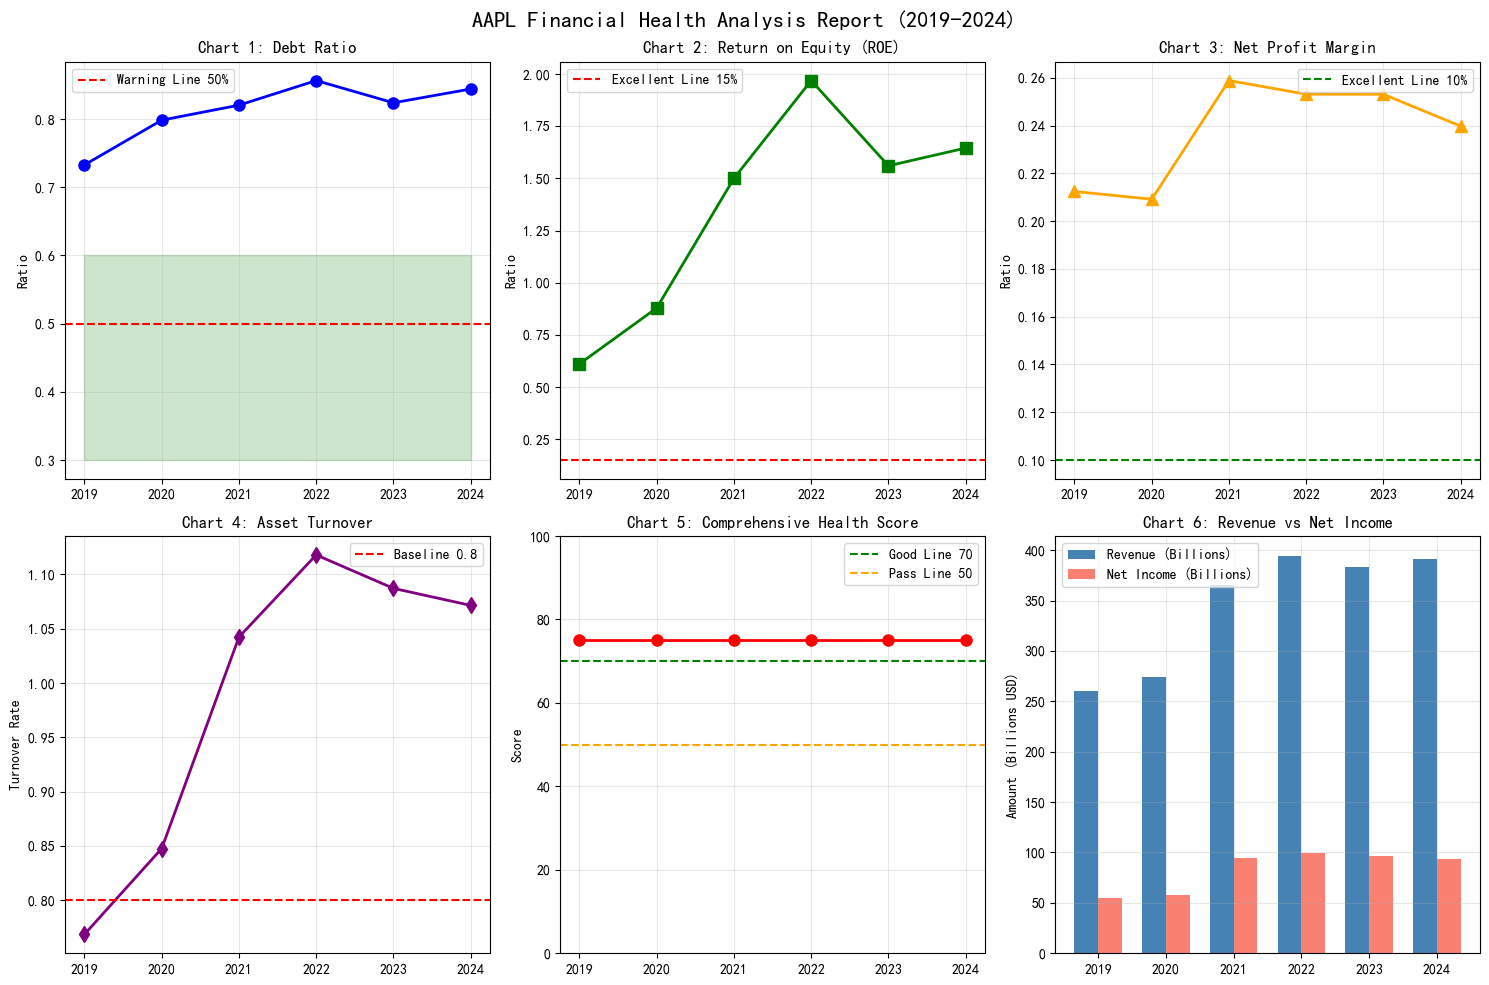

✅ 6 charts saved as AAPL_financial_analysis.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'{ticker} Financial Health Analysis Report (2019-2024)', fontsize=16, fontweight='bold')

years = df_scored['year'].tolist()

# Chart 1: Debt Ratio Trend
axes[0, 0].plot(years, df_scored['debt_ratio'].tolist(), color='blue', marker='o', linewidth=2, markersize=8)
axes[0, 0].axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='Warning Line 50%')
axes[0, 0].fill_between(years, 0.3, 0.6, alpha=0.2, color='green')
axes[0, 0].set_title('Chart 1: Debt Ratio', fontsize=12)
axes[0, 0].set_ylabel('Ratio')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Chart 2: ROE Trend
axes[0, 1].plot(years, df_scored['ROE'].tolist(), color='green', marker='s', linewidth=2, markersize=8)
axes[0, 1].axhline(y=0.15, color='red', linestyle='--', linewidth=1.5, label='Excellent Line 15%')
axes[0, 1].set_title('Chart 2: Return on Equity (ROE)', fontsize=12)
axes[0, 1].set_ylabel('Ratio')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Chart 3: Net Profit Margin Trend
axes[0, 2].plot(years, df_scored['net_profit_margin'].tolist(), color='orange', marker='^', linewidth=2, markersize=8)
axes[0, 2].axhline(y=0.10, color='green', linestyle='--', linewidth=1.5, label='Excellent Line 10%')
axes[0, 2].set_title('Chart 3: Net Profit Margin', fontsize=12)
axes[0, 2].set_ylabel('Ratio')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Chart 4: Asset Turnover Trend
axes[1, 0].plot(years, df_scored['asset_turnover'].tolist(), color='purple', marker='d', linewidth=2, markersize=8)
axes[1, 0].axhline(y=0.8, color='red', linestyle='--', linewidth=1.5, label='Baseline 0.8')
axes[1, 0].set_title('Chart 4: Asset Turnover', fontsize=12)
axes[1, 0].set_ylabel('Turnover Rate')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Chart 5: Health Score Trend
axes[1, 1].plot(years, df_scored['health_score'].tolist(), color='red', marker='o', linewidth=2, markersize=8)
axes[1, 1].axhline(y=70, color='green', linestyle='--', linewidth=1.5, label='Good Line 70')
axes[1, 1].axhline(y=50, color='orange', linestyle='--', linewidth=1.5, label='Pass Line 50')
axes[1, 1].set_title('Chart 5: Comprehensive Health Score', fontsize=12)
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0, 100)

# Chart 6: Revenue vs Net Income Comparison (Double bar chart)
x = range(len(years))
width = 0.35
axes[1, 2].bar([i - width/2 for i in x], (df_scored['revenue'] / 1000).tolist(), width, label='Revenue (Billions)', color='steelblue')
axes[1, 2].bar([i + width/2 for i in x], (df_scored['net_income'] / 1000).tolist(), width, label='Net Income (Billions)', color='salmon')
axes[1, 2].set_title('Chart 6: Revenue vs Net Income', fontsize=12)
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(years)
axes[1, 2].set_ylabel('Amount (Billions USD)')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{ticker}_financial_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ 6 charts saved as {ticker}_financial_analysis.png")

## 12. Generate Analysis Report

Output a structured text report containing:
- Latest year key financial data
- Trend analysis (score changes over time)
- Comprehensive evaluation and recommendations

In [121]:
print("\n" + "=" * 60)
print(f"📋 {ticker} Financial Health Analysis Report")
print("=" * 60)

latest = df_scored.iloc[-1]
first = df_scored.iloc[0]

print(f"\nAnalysis Period: {df_scored['year'].min()} - {df_scored['year'].max()} ({len(df_scored)} years)")

print(f"\n【Latest Year Data - {latest['year']}】")
print(f"  • Total Assets: {latest['total_assets']:,.0f} million USD")
print(f"  • Revenue: {latest['revenue']:,.0f} million USD")
print(f"  • Net Income: {latest['net_income']:,.0f} million USD")
print(f"  • Debt Ratio: {latest['debt_ratio']:.1%}")
print(f"  • ROE: {latest['ROE']:.1%}")
print(f"  • Net Profit Margin: {latest['net_profit_margin']:.1%}")
print(f"  • Health Score: {latest['health_score']:.0f} points")

# Trend analysis
print(f"\n【Trend Analysis】")
score_change = latest['health_score'] - first['health_score']
if score_change > 10:
    print(f"  • Health Score: Increased by {score_change:.0f} points 📈 Financial condition improving")
elif score_change < -10:
    print(f"  • Health Score: Decreased by {abs(score_change):.0f} points 📉 Financial condition deteriorating")
else:
    print(f"  • Health Score: Relatively stable")

# Comprehensive evaluation
print(f"\n【Comprehensive Evaluation】")
if latest['health_score'] >= 70:
    print("  ✅ Excellent - The company has a healthy financial condition with strong profitability and solvency")
elif latest['health_score'] >= 50:
    print("  ⚠️ Average - Financial condition is moderate, recommend monitoring key indicators")
else:
    print("  ❌ Caution - Financial condition requires attention, recommend in-depth analysis")

print("\n" + "=" * 60)


📋 AAPL Financial Health Analysis Report

Analysis Period: 2019 - 2024 (6 years)

【Latest Year Data - 2024】
  • Total Assets: 364,980 million USD
  • Revenue: 391,035 million USD
  • Net Income: 93,736 million USD
  • Debt Ratio: 84.4%
  • ROE: 164.6%
  • Net Profit Margin: 24.0%
  • Health Score: 75 points

【Trend Analysis】
  • Health Score: Relatively stable

【Comprehensive Evaluation】
  ✅ Excellent - The company has a healthy financial condition with strong profitability and solvency



## 13. Save Results to Excel

Save the complete analysis results (including raw data and calculated ratios) to an Excel file:
`{ticker}_financial_analysis_results.xlsx`

This allows for further analysis or sharing with non-technical users.

In [112]:
# Save Excel file
excel_file = f'{ticker}_financial_analysis_results.xlsx'
df_scored.to_excel(excel_file, index=False)

print(f"✅ Analysis results saved to {excel_file}")
print("\nColumns saved:")
print(df_scored.columns.tolist())

✅ Analysis results saved to MSFT_financial_analysis_results.xlsx

Columns saved:
['ticker', 'year', 'total_assets', 'total_liabilities', 'total_equity', 'revenue', 'net_income', 'debt_ratio', 'equity_multiplier', 'ROE', 'net_profit_margin', 'asset_turnover', 'health_score']


## 14. Close Database Connection

Release the WRDS database connection resource.

In [ ]:
db.close()

##  Analysis Complete

This notebook demonstrates a complete financial data analysis workflow:

1. Data acquisition (WRDS Compustat + CRSP)
2. Data cleaning and preprocessing
3. Financial ratio calculation
4. Health scoring model
5. Visualization report generation
6. Results export

**Output Files**:
- `{ticker}_financial_analysis.png` - 6-in-1 trend charts
- `{ticker}_financial_analysis_results.xlsx` - Complete data table

**Limitations**:
- Analysis covers only 6 years; longer trends require more data
- Scoring model weights are simplified and not statistically validated
- Industry differences not considered
- Cash flow indicators not included

**Future Improvements**:
- Add cash flow analysis (CFO, FCF)
- Compare with industry averages
- Add predictive models (e.g., Altman Z-score)